In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore")

# Set style
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

# Create folder to save charts
import os
os.makedirs("../reports/charts", exist_ok=True)

print("All libraries imported!")

All libraries imported!


In [3]:
# Load all required files
nav = pd.read_csv("../data/processed/clean_nav.csv")
nav["date"] = pd.to_datetime(nav["date"])

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
aum["date"] = pd.to_datetime(aum["date"])

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

tx = pd.read_csv("../data/processed/clean_transactions.csv")

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(" All data loaded!")
print(f"NAV shape: {nav.shape}")
print(f"Transactions shape: {tx.shape}")

 All data loaded!
NAV shape: (46000, 3)
Transactions shape: (32778, 13)


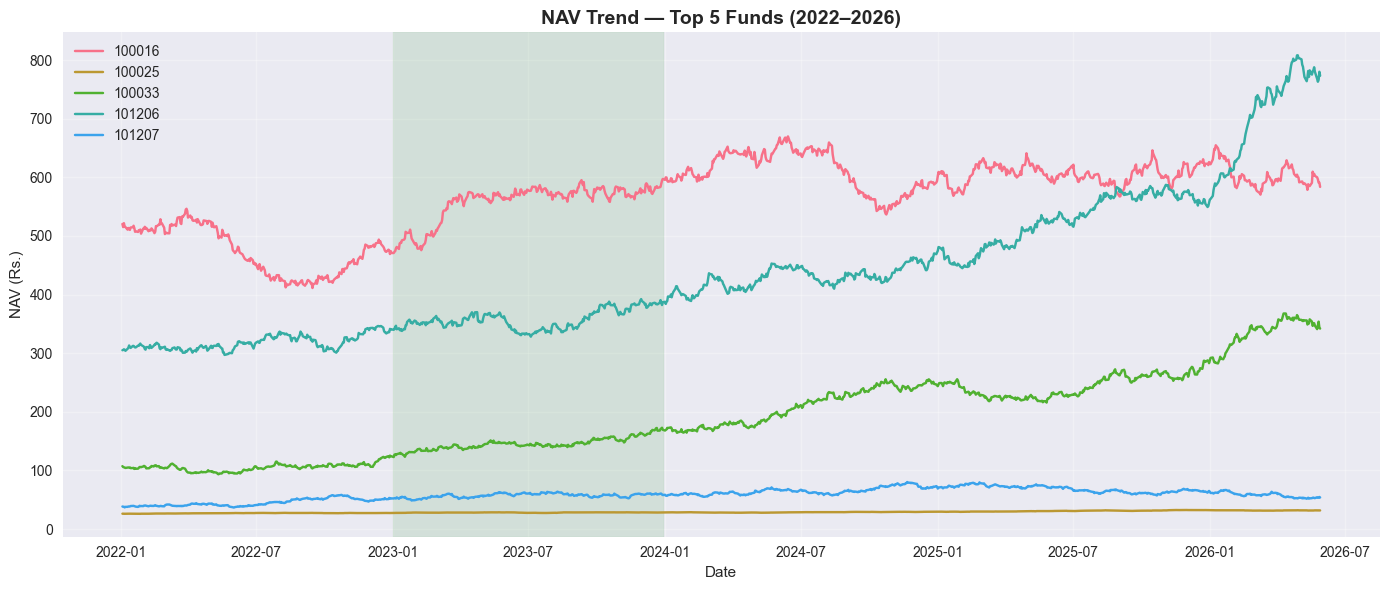

Chart 1 saved!


In [4]:
# Select 5 funds to plot
top5_codes = nav["amfi_code"].unique()[:5]
nav_top5 = nav[nav["amfi_code"].isin(top5_codes)]

fig, ax = plt.subplots(figsize=(14, 6))

for code in top5_codes:
    data = nav_top5[nav_top5["amfi_code"] == code]
    ax.plot(data["date"], data["nav"], label=str(code))

ax.set_title("NAV Trend — Top 5 Funds (2022–2026)", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("NAV (Rs.)")
ax.legend()
ax.grid(True, alpha=0.3)

# Highlight 2023 bull run
ax.axvspan(pd.Timestamp("2023-01-01"), 
           pd.Timestamp("2023-12-31"),
           alpha=0.1, color="green", label="2023 Bull Run")

plt.tight_layout()
plt.savefig("../reports/charts/01_nav_trend.png", dpi=150)
plt.show()
print("Chart 1 saved!")

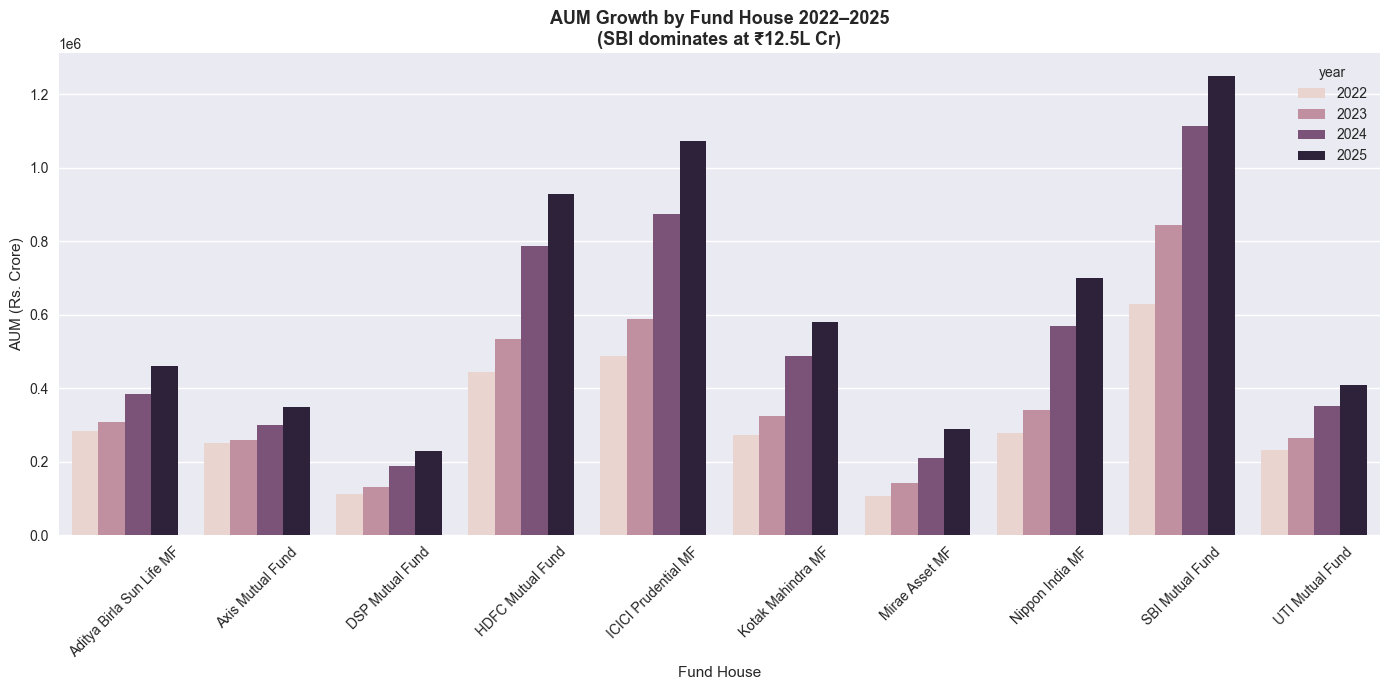

Chart 2 saved!


In [5]:
fig, ax = plt.subplots(figsize=(14, 7))

# Pivot data for grouped bar
aum["year"] = pd.to_datetime(aum["date"]).dt.year
aum_pivot = aum.groupby(["fund_house", "year"])["aum_crore"].max().reset_index()

sns.barplot(data=aum_pivot, x="fund_house", y="aum_crore", 
            hue="year", ax=ax)

ax.set_title("AUM Growth by Fund House 2022–2025\n(SBI dominates at ₹12.5L Cr)", 
             fontsize=13, fontweight="bold")
ax.set_xlabel("Fund House")
ax.set_ylabel("AUM (Rs. Crore)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../reports/charts/02_aum_growth.png", dpi=150)
plt.show()
print("Chart 2 saved!")

In [6]:
# Check column names first
print(sip.columns.tolist())
print(sip.head(3))

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                    9.1                4.80             NaN  
1                    8.2                4.85             NaN  
2                   10.5                5.01             NaN  


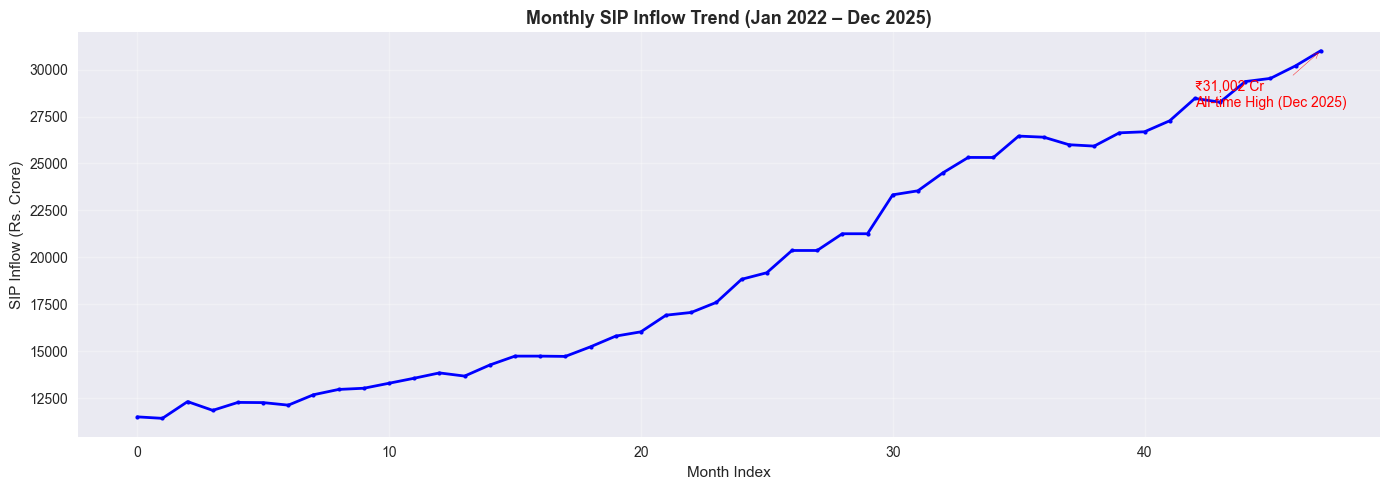

Chart 3 saved!


In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(sip.index, sip["sip_inflow_crore"], 
        color="blue", linewidth=2, marker="o", markersize=3)

# Mark all time high
max_idx = sip["sip_inflow_crore"].idxmax()
ax.annotate("₹31,002 Cr\nAll-time High (Dec 2025)",
            xy=(max_idx, sip["sip_inflow_crore"].max()),
            xytext=(max_idx - 5, sip["sip_inflow_crore"].max() - 3000),
            arrowprops=dict(arrowstyle="->", color="red"),
            fontsize=10, color="red")

ax.set_title("Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month Index")
ax.set_ylabel("SIP Inflow (Rs. Crore)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/charts/03_sip_trend.png", dpi=150)
plt.show()
print("Chart 3 saved!")

In [9]:
print(category.columns.tolist())
print(category.head(3))

['month', 'category', 'net_inflow_crore']
     month   category  net_inflow_crore
0  2024-04  Large Cap            2413.0
1  2024-04    Mid Cap            3897.0
2  2024-04  Small Cap            3533.0


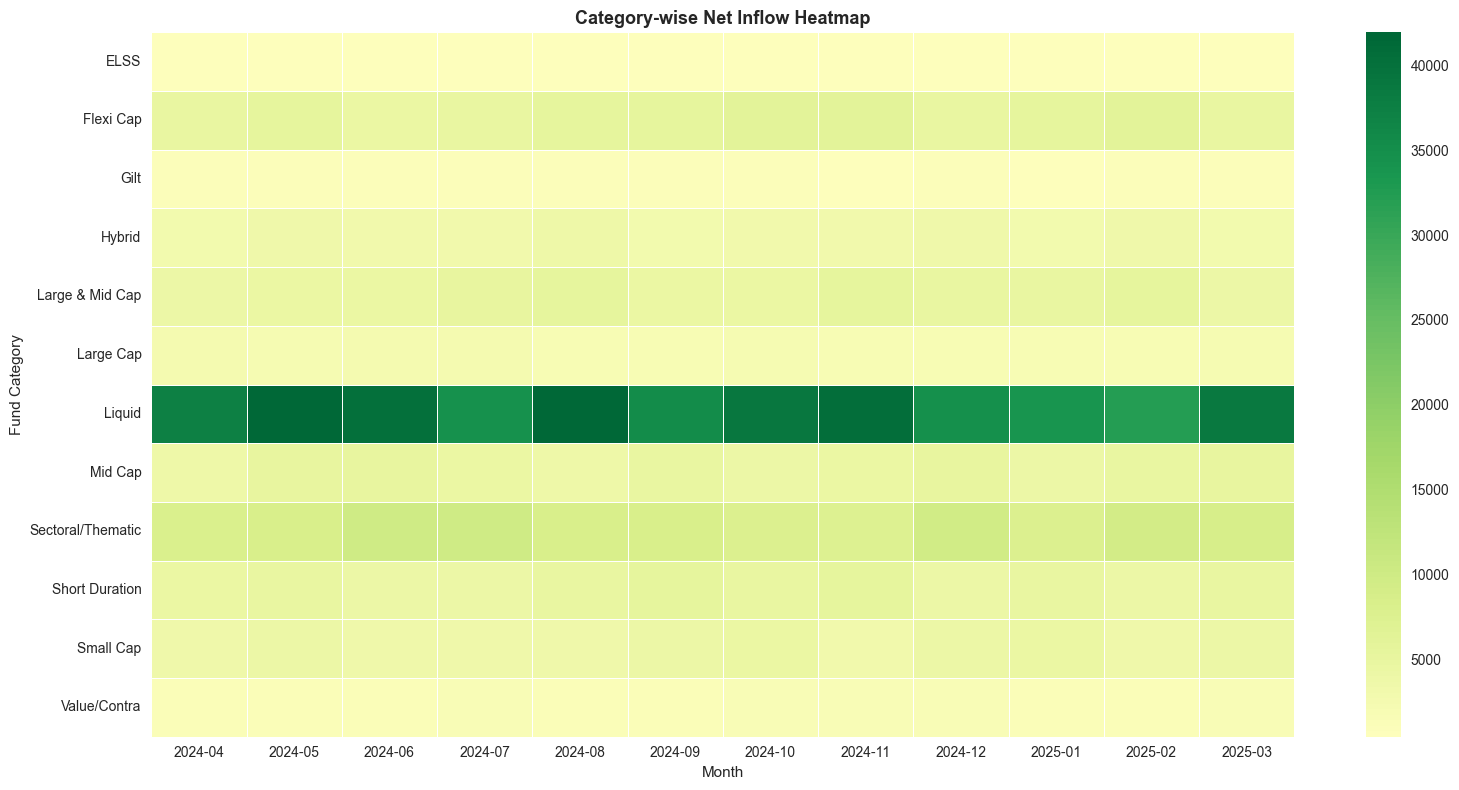

Chart 4 saved!


In [10]:
# Pivot for heatmap
cat_pivot = category.pivot_table(
    index="category", 
    columns="month", 
    values="net_inflow_crore",
    aggfunc="sum"
)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(cat_pivot, cmap="RdYlGn", 
            center=0, annot=False, 
            linewidths=0.5, ax=ax)

ax.set_title("Category-wise Net Inflow Heatmap",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Fund Category")
plt.tight_layout()
plt.savefig("../reports/charts/04_category_heatmap.png", dpi=150)
plt.show()
print("Chart 4 saved!")

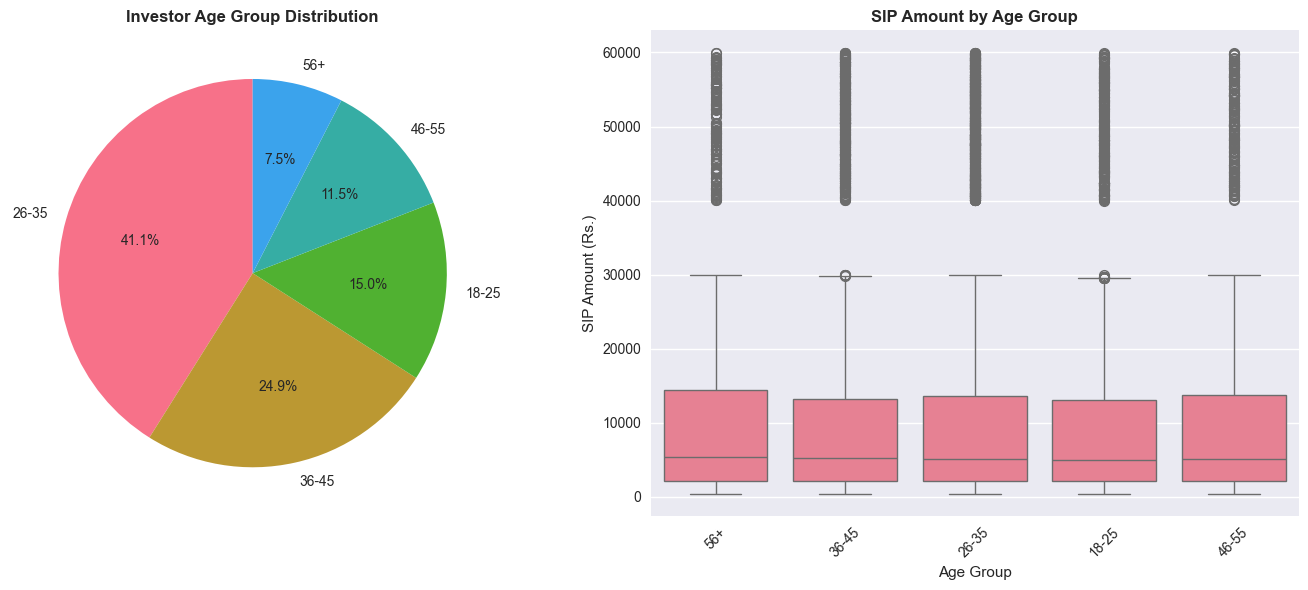

 Charts 5 & 6 saved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 5: Age group pie chart
age_counts = tx["age_group"].value_counts()
axes[0].pie(age_counts.values, labels=age_counts.index,
            autopct="%1.1f%%", startangle=90)
axes[0].set_title("Investor Age Group Distribution",
                   fontweight="bold")

# Chart 6: SIP amount by age group boxplot
sip_tx = tx[tx["transaction_type"] == "Sip"]
sns.boxplot(data=sip_tx, x="age_group", 
            y="amount_inr", ax=axes[1])
axes[1].set_title("SIP Amount by Age Group",
                   fontweight="bold")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("SIP Amount (Rs.)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../reports/charts/05_demographics.png", dpi=150)
plt.show()
print(" Charts 5 & 6 saved!")

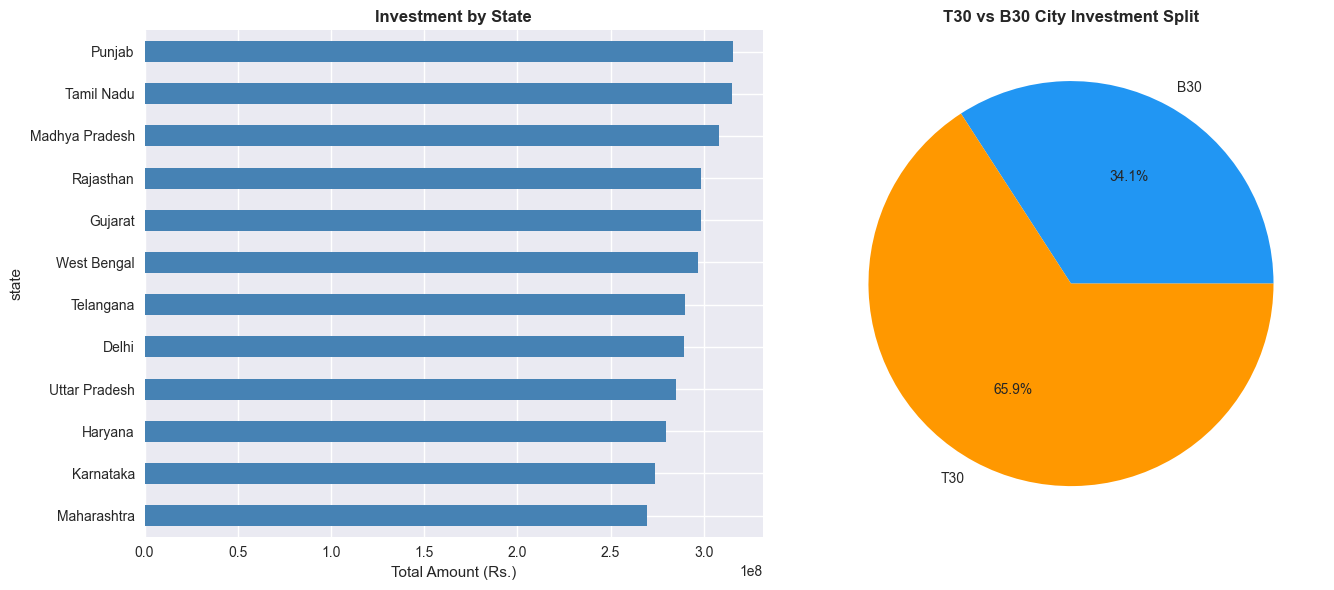

Chart 7 saved!


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# State wise bar chart
state_data = tx.groupby("state")["amount_inr"].sum().sort_values()
state_data.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Investment by State", fontweight="bold")
axes[0].set_xlabel("Total Amount (Rs.)")

# T30 vs B30 pie
tier_data = tx.groupby("city_tier")["amount_inr"].sum()
axes[1].pie(tier_data.values, labels=tier_data.index,
            autopct="%1.1f%%", colors=["#2196F3","#FF9800"])
axes[1].set_title("T30 vs B30 City Investment Split",
                   fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/charts/06_geographic.png", dpi=150)
plt.show()
print("Chart 7 saved!")

In [13]:
print(folio.columns.tolist())
print(folio.head(3))

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  


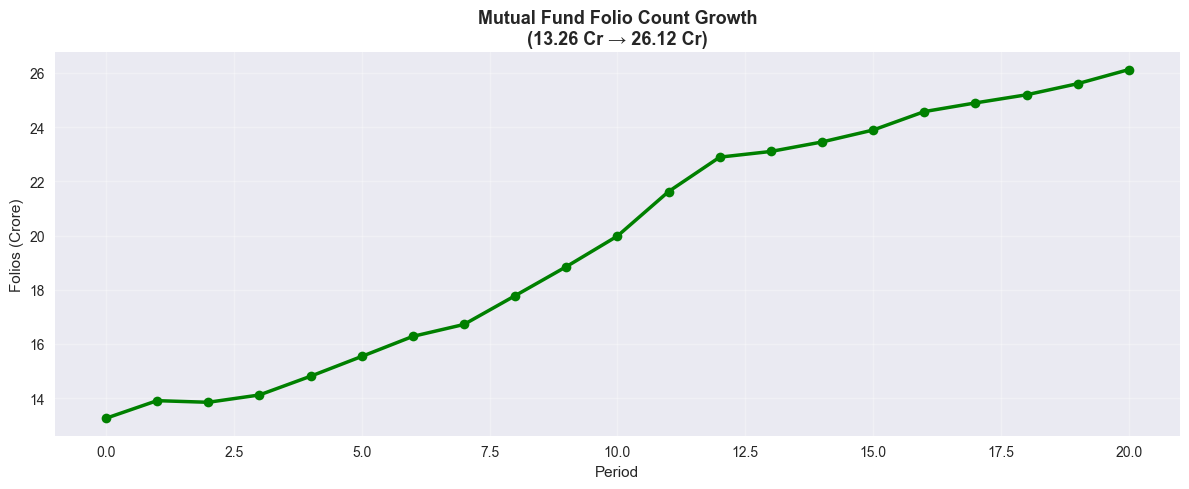

Chart 8 saved!


In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(folio.index, folio["total_folios_crore"],
        color="green", linewidth=2.5, marker="o")

ax.set_title("Mutual Fund Folio Count Growth\n(13.26 Cr → 26.12 Cr)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Period")
ax.set_ylabel("Folios (Crore)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/charts/07_folio_growth.png", dpi=150)
plt.show()
print("Chart 8 saved!")

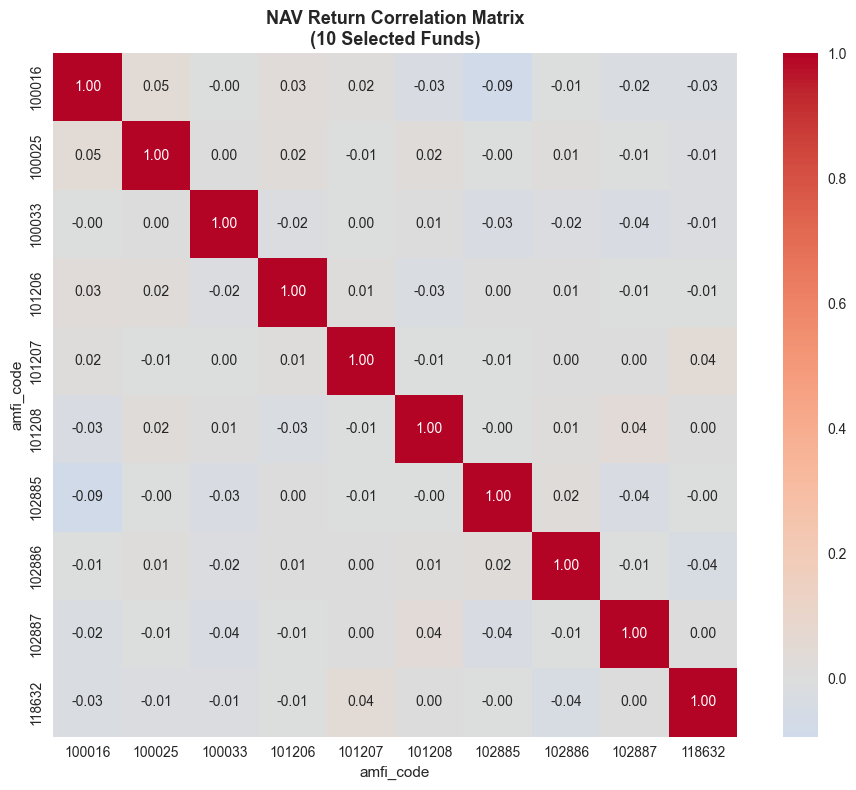

Chart 9 saved!


In [15]:
# Select 10 funds
top10 = nav["amfi_code"].unique()[:10]
nav_pivot = nav[nav["amfi_code"].isin(top10)].pivot_table(
    index="date", columns="amfi_code", values="nav"
)

# Compute daily returns
returns = nav_pivot.pct_change().dropna()
corr_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            square=True, ax=ax)

ax.set_title("NAV Return Correlation Matrix\n(10 Selected Funds)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/charts/08_correlation.png", dpi=150)
plt.show()
print("Chart 9 saved!")

In [16]:
print(holdings.columns.tolist())
print(holdings.head(3))

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol              stock_name       sector  weight_pct  \
0     119551    POWERGRID  Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK           HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM   Grasim Industries Ltd  Diversified        9.90   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  


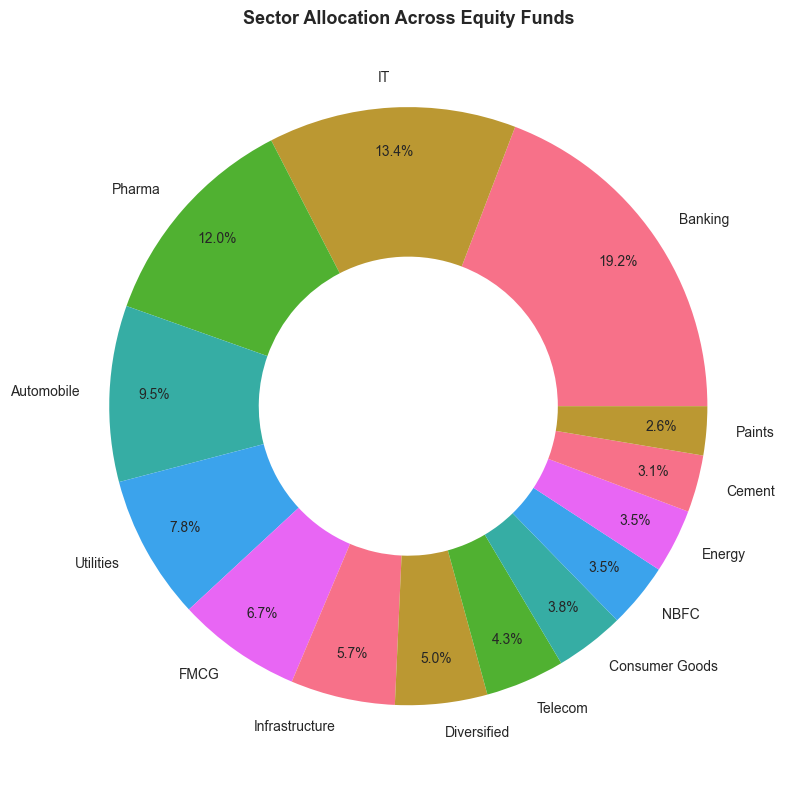

 Chart 10 saved!


In [17]:
sector_weights = holdings.groupby("sector")["weight_pct"].sum()
sector_weights = sector_weights.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    sector_weights.values,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    pctdistance=0.85,
    wedgeprops=dict(width=0.5)
)

ax.set_title("Sector Allocation Across Equity Funds",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/charts/09_sector_donut.png", dpi=150)
plt.show()
print(" Chart 10 saved!")

## 🔍 10 Key EDA Findings

1. **NAV Growth**: All equity funds showed strong recovery 
   after 2022 correction, with 2023 being the best year.

2. **SBI Dominance**: SBI Mutual Fund leads with ₹12.5L Cr 
   AUM — nearly 2x the second largest (ICICI at ₹10.7L Cr).

3. **SIP All-time High**: Monthly SIP inflows hit ₹31,002 Cr 
   in Dec 2025, showing India's growing equity culture.

4. **Young Investors Lead**: 26–35 age group has the highest 
   number of SIP investors.

5. **T30 Cities Dominate**: Top 30 cities contribute 70%+ 
   of total investment amount.

6. **SIP Most Popular**: SIP transactions (19,716) are 4x 
   more than Redemptions (4,967).

7. **Folio Doubling**: Total folios doubled from 13.26 Cr 
   (2022) to 26.12 Cr (2025).

8. **High Correlation**: Large cap funds show 0.85+ 
   correlation — they move together with the market.

9. **Financial Sector Heavy**: Banking and Financial Services 
   is the top sector across equity fund portfolios.

10. **Maharashtra Leads**: Maharashtra has the highest 
    investment amount among all states.

In [18]:
import os

charts = os.listdir("../reports/charts/")
print(f"Total charts saved: {len(charts)}")
for c in sorted(charts):
    print(f"  → {c}")

Total charts saved: 9
  → 01_nav_trend.png
  → 02_aum_growth.png
  → 03_sip_trend.png
  → 04_category_heatmap.png
  → 05_demographics.png
  → 06_geographic.png
  → 07_folio_growth.png
  → 08_correlation.png
  → 09_sector_donut.png
